In [1]:
import pandas as pd

In [3]:
dataset=pd.read_csv("Placement.csv")

In [4]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [5]:
quan=[]
qual=[]
for columnName in dataset.columns:
    if(dataset[columnName].dtype=='str'):
        qual.append(columnName)
    else:
        quan.append(columnName)

In [7]:
for columnName in quan:
    dataset[columnName]=dataset[columnName].fillna(0)

In [8]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [12]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    sample=dataset
    sample_mean=sample.mean()
    sample_std=sample.std()
    print("Mean=%.3f Standard Deviation=%.3f"%(sample_mean,sample_std))
    dist=norm(sample_mean,sample_std)
    values=[values for value in range (startrange,endrange)]
    probabilities=[dist.pdf(value) for value in values]
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,prob))
    return prob    
    

C:\Users\NEW\AppData\Local\Temp\ipykernel_2144\870395871.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


Mean=67.303 Standard Deviation=10.827


NameError: cannot access free variable 'values' where it is not associated with a value in enclosing scope

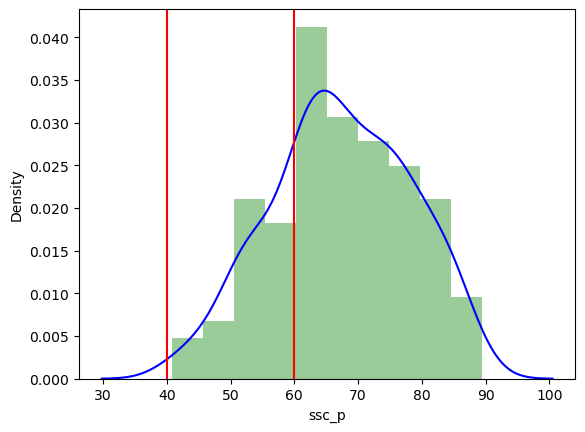

In [13]:
get_pdf_probability(dataset["ssc_p"],40,60)

In [15]:
!pip install statsmodels 

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 7.2 MB/s eta 0:00:02
   ----- ---------------------------------- 1.3/9.6 MB 3.5 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 4.7 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 4.2 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.6 MB 4.1 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.6 MB 4.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 4.0 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 4.0 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 4.0 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 3.9 MB/s  0:00:02

   ------------------

from statsmodel.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset["ssc_p"])
ecdf(78)

In [17]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset["ssc_p"])

In [21]:
ecdf(78).item()

0.827906976744186